In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X=data.data
y=data.target 


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (455, 30)
Test Shape: (114, 30)


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

param_gird = {
    "model__C": [0.01, 0.1, 1, 10],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_gird,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'model__C': 0.1}
Best CV accuracy: 0.9802197802197803


# Accuracy

In [4]:
from sklearn.metrics import accuracy_score

# Best model from GridSearchCV
best_model = grid.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")


Train accuracy: 0.9868
Test accuracy:  0.9737


# Confusion Matrix

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

cm= confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:\n",cm)

# Detailed metrics
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Confusion matrix:
 [[40  2]
 [ 1 71]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Confusion Matrix – Concise Insight

### Class mapping
- **0 → Malignant (critical)**
- **1 → Benign**

### Summary of outcomes
- **Malignant correctly detected:** 40  
- **Malignant missed (FN):** 2  
- **Benign wrongly flagged (FP):** 1  
- **Benign correctly detected:** 71  

### Key takeaways
- **Low false negatives (2)** → Rarely misses cancer cases (most important clinically).
- **Low false positives (1)** → Minimal unnecessary alarms.
- **High recall for malignant (0.95)** → Strong cancer detection capability.
- **High precision for malignant (0.98)** → Predictions of cancer are highly reliable.
- **Balanced metrics** → No class bias; stable generalization.

### Bottom line
The model is **accurate, well-balanced, and clinically safe**, making it suitable for **probability-based evaluation and threshold tuning using ROC–AUC**.


In [6]:
from sklearn.metrics import precision_score, f1_score, recall_score

precision = precision_score(y_test, y_test_pred)
print("Precision:",precision)
recall = recall_score(y_test, y_test_pred)
print("Recall:",recall)
f1 = f1_score(y_test, y_test_pred)
print("f1:",f1)

Precision: 0.9726027397260274
Recall: 0.9861111111111112
f1: 0.9793103448275862


# ROC Curve (Receiver Operating Characteristic)

## What is it?
The **ROC curve** is a graph that illustrates the performance of a classification model at **all classification thresholds**.
It plots two parameters:
1.  **True Positive Rate (TPR)**: Same as **Recall** or **Sensitivity**.
    $$\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
2.  **False Positive Rate (FPR)**: The proportion of actual negatives that were incorrectly classified as positive.
    $$\text{FPR} = \frac{\text{FP}}{\text{TN} + \text{FP}}$$

## Why do we use it?
- **Threshold Independence**: Accuracy depends on a fixed threshold (usually 0.5). The ROC curve shows how the model performs **regardless of the threshold chosen**.
- **Trade-off Visualization**: It visualizes the trade-off between catching positive cases (High TPR) vs. raising false alarms (High FPR).
- **Imbalanced Data**: It is often more informative than accuracy when classes are imbalanced.

## When to use it?
- When you care about **ranking** predictions (probabilities) rather than just hard classes.
- When the costs of False Positives and False Negatives are different, and you need to choose an optimal threshold.

## What is AUC (Area Under the Curve)?
- **AUC** provides an aggregate measure of performance across all possible classification thresholds.
- **Range**: 0.0 to 1.0.
- **Interpretation**:
  - **AUC = 1.0**: Perfect model. Can perfectly separate positive and negative classes.
  - **AUC = 0.5**: Random guessing. No discriminative power.
  - **AUC < 0.5**: Worse than random (model is flipping classes).
  - **AUC > 0.7**: Generally considered acceptable.
  - **AUC > 0.9**: Excellent model.


    AUC stands for Area Under the ROC Curve.

    ROC → the curve (TPR vs FPR across thresholds)

    AUC → the single numeric summary of that curve

ROC-AUC score: 0.9957


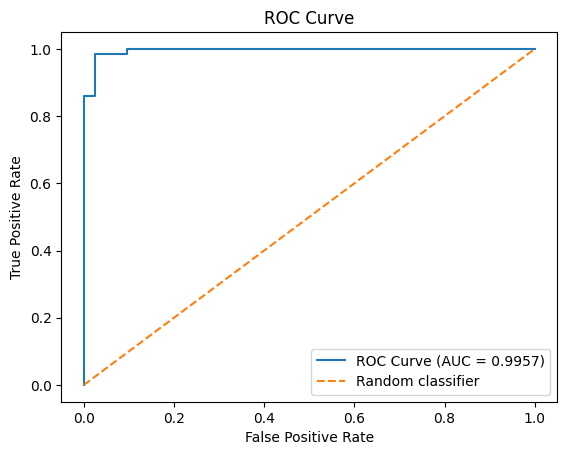

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities for the positive class (class = 1)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"ROC-AUC score: {roc_auc:.4f}")

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### Why `predict_proba(X)[:, 1]` is used

`predict_proba` returns a 2D array of shape `(n_samples, 2)`:

- Column `0` → `P(class = 0)`
- Column `1` → `P(class = 1)` (positive class)

```python
best_model.predict_proba(X_test)[i] = [P(y=0 | x_i), P(y=1 | x_i)]
````

Using `[:, 1]` selects the **probability of the positive class** for all samples:

```python
y_test_proba = best_model.predict_proba(X_test)[:, 1]
```

ROC and ROC–AUC require **continuous scores for the positive class** to evaluate how well the model separates classes across all thresholds.

> **Rule:** ROC–AUC always uses the probability of the positive class (by convention, class `1`).


### ROC Curve: Key Relationship & Intuition

**Key relationship**
- For each index `i`:
  - `thresholds[i]` → produces one point `(fpr[i], tpr[i])`
- Each ROC point corresponds to:
  - **One decision threshold**
  - **One (FPR, TPR) pair**

**Intuition**
- **High threshold (strict decision)**  
  → Few positives predicted  
  → **Low FPR**, **Low TPR**

- **Low threshold (lenient decision)**  
  → Many positives predicted  
  → **High FPR**, **High TPR**

ROC visualizes this trade-off across **all possible thresholds**.


# Regression 

In [8]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split 

data = load_diabetes()

X=data.data 
y=data.target

X_train, X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
print("Train shape", X_train.shape)
print("Test shape", X_test.shape)


Train shape (353, 10)
Test shape (89, 10)


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import numpy as np

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

# param_gird = {
#     "model_alpha":[0.01, 0.1, 10, 100]
# }
param_gird = {
    "model__alpha": np.logspace(-3,3,7)
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_gird,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best DV R2 score:",grid.best_score_)

Best parameters: {'model__alpha': np.float64(10.0)}
Best DV R2 score: 0.45393741579593494


R² is preferred for model selection, MAE/MSE/RMSE are preferred for error interpretation.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# Best model from GridSearchCV
best_model = grid.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train Metrics")
print(f"MAE:  {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R2:   {train_r2:.3f}")

print("\nTest Metrics")
print(f"MAE:  {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R2:   {test_r2:.3f}")


Train Metrics
MAE:  43.64
RMSE: 53.74
R2:   0.525

Test Metrics
MAE:  42.86
RMSE: 53.63
R2:   0.457


In [20]:
import pandas as pd 
target = pd.Series(data.target, name="target")

target.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [31]:
MEAN = 152.13348416289594
MIN = 25.0
MAX = 346.0 
Q1 = 87.0
Q3 = 211.5 
IQR = Q3-Q1 
RANGE = MAX - MIN 

print(f"models average predict error is {test_mae/MEAN *100:.2f}% ")
print("or")
print(f"Model MAE is {test_mae / MEAN * 100:.2f}% of the target mean")
print(f"Model MAE is {test_mae / RANGE * 100:.2f}% of the target range")
print(f"Model MAE is {test_mae / IQR * 100:.2f}% of the target IQR")

models average predict error is 28.17% 
or
Model MAE is 28.17% of the target mean
Model MAE is 13.35% of the target range
Model MAE is 34.42% of the target IQR


## Interpreting MAE as a Percentage (Mean, Range, IQR)

### 1. MAE as % of Target Mean
- **Meaning:** On average, the model’s predictions deviate by **X%** from a typical (mean) target value.
- **Intuition:** The model is typically off by **~28% of an average case**.

---

### 2. MAE as % of Target Range
- **Meaning:** The average prediction error expressed relative to the **full spread** of possible target values.
- **Intuition:** The model is typically off by **~13% of the total possible spread**.

---

### 3. MAE as % of Target IQR
- **Meaning:** The average prediction error expressed relative to the **interquartile range (middle 50%)** of the target distribution.
- **Intuition:** The model is typically off by **~34% of the typical middle spread**, making this measure **robust to outliers**.

---

### Summary
- **Mean-based** → error relative to a typical value  
- **Range-based** → error relative to the full data spread  
- **IQR-based** → error relative to the central, outlier-resistant spread


In [39]:
print(f"RMSE is {((test_rmse / test_mae) - 1) * 100:.2f}% higher than MAE")

RMSE is 25.13% higher than MAE


### RMSE vs MAE Insight

RMSE being **X% higher than MAE** indicates that **larger errors exist and are penalized more heavily**.  
If this percentage is small, errors are fairly uniform; if it is large, the model occasionally makes **large mistakes** that RMSE amplifies.

In this case, the gap suggests **moderate outliers**, but not extreme instability.


In [43]:
print(f"R² generalization gap (train − test): {train_r2 - test_r2:.2f}")

R² generalization gap (train − test): 0.07


### R² Generalization Gap

The **R² generalization gap (train − test)** measures how much performance drops from training to unseen data.

- **Small gap** → model generalizes well  
- **Large gap** → possible overfitting  

A small positive value here indicates **stable generalization** with no serious overfitting.


# Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

# Use the best model found earlier
best_model = grid.best_estimator_

# Cross-validation on training data
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:", cv_scores)
print(f"Mean CV R²: {cv_scores.mean():.3f}")
print(f"Std CV R²:  {cv_scores.std():.3f}")


Cross-validation R² scores: [0.53988382 0.37610142 0.49973558 0.61034657 0.24361968]
Mean CV R²: 0.454
Std CV R²:  0.130


## Cross-Validation Insight (R²)

- **Fold-wise R² scores** show noticeable variation, ranging from **~0.24 to ~0.61**, indicating that model performance depends on the data split.
- **Mean CV R² ≈ 0.45** represents the model’s expected performance on unseen data and aligns well with the test R², suggesting a reliable evaluation.
- **Std CV R² ≈ 0.13** indicates moderate variability across folds, which is typical for a small and noisy dataset.

### Overall conclusion
The model provides a **reasonable and stable baseline** with no signs of overfitting, but the variability across folds suggests that **non-linear models may achieve better performance**.


----
----

### What the Cross-Validation R² Scores Represent

Each value in the list is the **R² score from one cross-validation fold**:

```

[0.54, 0.38, 0.50, 0.61, 0.24]

```

- The training data was split into **5 folds**
- For each fold:
  - The model was trained on **4 folds**
  - Evaluated on the **remaining 1 fold**
- Each number shows **how well the model explained variance on that validation split**

### How to read them
- **Higher R²** → better fit on that fold  
- **Variation across values** → sensitivity to data splits  

Together, these scores show **both performance and stability** of the model across different subsets of the data.


### Mean and Standard Deviation of CV R²

- **Mean CV R² (0.454):**  
  Represents the **average expected performance** of the model on unseen data across different splits.

- **Std CV R² (0.130):**  
  Measures how much the model’s performance **varies across folds**.  
  A moderate value indicates some sensitivity to data splits, which is common for small or noisy datasets.

**Interpretation:**  
The model has **consistent average performance**, with **moderate variability**, and no signs of severe overfitting.


### Interpreting Mean and Std of CV R²

**Mean CV R² (0.454)**  
- Represents the model’s **expected generalization performance** on unseen data  
- **Higher is better**  
- Values close to the test R² indicate a reliable evaluation

**Std CV R² (0.130)**  
- Measures **how much performance varies across folds**  
- **Lower is better** → more stable and reliable model  
- Higher values indicate sensitivity to how the data is split

### Rule of thumb
- **High mean + low std** → strong and stable model  
- **Moderate mean + moderate std** → acceptable baseline (your case)  
- **Low mean + high std** → weak or unstable model

These two together tell you **how good the model is and how trustworthy that score is**.
